In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [3]:
df = pd.read_csv('Dataset.csv')
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
df.head()

Shape: (3900, 18)

Columns: ['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Payment Method', 'Frequency of Purchases']


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.10,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.10,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.10,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.50,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.70,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [4]:
print('Data Types:')
print(df.dtypes)
print('\nMissing Values:')
print(df.isnull().sum())

Data Types:
Customer ID                 int64
Age                         int64
Gender                     object
Item Purchased             object
Category                   object
Purchase Amount (USD)       int64
Location                   object
Size                       object
Color                      object
Season                     object
Review Rating             float64
Subscription Status        object
Shipping Type              object
Discount Applied           object
Promo Code Used            object
Previous Purchases          int64
Payment Method             object
Frequency of Purchases     object
dtype: object

Missing Values:
Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status       

In [5]:
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')
print('Cleaned columns:', df.columns.tolist())

Cleaned columns: ['Customer_ID', 'Age', 'Gender', 'Item_Purchased', 'Category', 'Purchase_Amount_USD', 'Location', 'Size', 'Color', 'Season', 'Review_Rating', 'Subscription_Status', 'Shipping_Type', 'Discount_Applied', 'Promo_Code_Used', 'Previous_Purchases', 'Payment_Method', 'Frequency_of_Purchases']


In [6]:
median_rating = df['Review_Rating'].median()
df['Review_Rating'] = df['Review_Rating'].fillna(median_rating)
print(f'Filled missing ratings with median: {median_rating}')
print('Missing values remaining:', df.isnull().sum().sum())

Filled missing ratings with median: 3.8
Missing values remaining: 0


In [7]:
binary_cols = ['Discount_Applied', 'Promo_Code_Used', 'Subscription_Status']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})
print('Done:')
df[binary_cols].head()

Done:


,Discount_Applied,Promo_Code_Used,Subscription_Status
0,1,1,1
1,1,1,1
2,1,1,1
3,1,1,1
4,1,1,1


In [8]:
frequency_map = {
    'Weekly': 7,
    'Bi-Weekly': 6,
    'Fortnightly': 5,
    'Monthly': 4,
    'Every 3 Months': 3,
    'Quarterly': 2,
    'Annually': 1
}
df['Frequency_Score'] = df['Frequency_of_Purchases'].map(frequency_map)
print(df[['Frequency_of_Purchases', 'Frequency_Score']].drop_duplicates().sort_values('Frequency_Score', ascending=False))

   Frequency_of_Purchases  Frequency_Score
2                  Weekly                7
10              Bi-Weekly                6
0             Fortnightly                5
15                Monthly                4
20         Every 3 Months                3
6               Quarterly                2
4                Annually                1


In [9]:
# What it captures: How reliant is this customer on discounts to buy?
# 1.0 = always uses discount + promo | 0.0 = never uses either
df['Promo_Dependency_Score'] = (df['Discount_Applied'] + df['Promo_Code_Used']) / 2
print('Promo Dependency Score distribution:')
print(df['Promo_Dependency_Score'].value_counts().sort_index())

Promo Dependency Score distribution:
Promo_Dependency_Score
0.00    2223
1.00    1677
Name: count, dtype: int64


In [10]:
# What it captures: Overall customer worth = spend + frequency combined
df['Amount_Normalized'] = (df['Purchase_Amount_USD'] - df['Purchase_Amount_USD'].min()) / \
                           (df['Purchase_Amount_USD'].max() - df['Purchase_Amount_USD'].min())

df['Frequency_Normalized'] = (df['Frequency_Score'] - df['Frequency_Score'].min()) / \
                               (df['Frequency_Score'].max() - df['Frequency_Score'].min())

# 60% weight on spend, 40% on frequency
df['Value_Score'] = (0.6 * df['Amount_Normalized']) + (0.4 * df['Frequency_Normalized'])
df['Value_Tier'] = pd.qcut(df['Value_Score'], q=4, labels=['Low', 'Medium', 'High', 'Premium'])

print('Value Tier distribution:')
print(df['Value_Tier'].value_counts().sort_index())

Value Tier distribution:
Value_Tier
Low        975
Medium     977
High       978
Premium    970
Name: count, dtype: int64


In [11]:
# Loyal = buys frequently + has purchase history + doesn't need promos
df['Loyalty_Def1'] = (
    (df['Frequency_Score'] >= 4) &
    (df['Previous_Purchases'] >= 25) &
    (df['Promo_Dependency_Score'] <= 0.5)
).astype(int)

print(f"Loyal customers (Def 1): {df['Loyalty_Def1'].sum()} ({df['Loyalty_Def1'].mean()*100:.1f}%)")

Loyal customers (Def 1): 627 (16.1%)


In [12]:
# Loyal = spends above median + satisfied + subscribed
df['Loyalty_Def2'] = (
    (df['Purchase_Amount_USD'] >= df['Purchase_Amount_USD'].median()) &
    (df['Review_Rating'] >= 4.0) &
    (df['Subscription_Status'] == 1)
).astype(int)

print(f"Loyal customers (Def 2): {df['Loyalty_Def2'].sum()} ({df['Loyalty_Def2'].mean()*100:.1f}%)")

Loyal customers (Def 2): 232 (5.9%)


In [13]:
rev_def1 = df[df['Loyalty_Def1']==1]['Purchase_Amount_USD'].mean()
rev_def2 = df[df['Loyalty_Def2']==1]['Purchase_Amount_USD'].mean()
prev_def1 = df[df['Loyalty_Def1']==1]['Previous_Purchases'].mean()
prev_def2 = df[df['Loyalty_Def2']==1]['Previous_Purchases'].mean()
promo_def1 = df[df['Loyalty_Def1']==1]['Promo_Dependency_Score'].mean()
promo_def2 = df[df['Loyalty_Def2']==1]['Promo_Dependency_Score'].mean()

print('=== WHICH DEFINITION IS BETTER? ===')
print(f'\nDef 1 (Behavioral): Avg Spend=${rev_def1:.2f} | Prev Purchases={prev_def1:.1f} | Promo Dependency={promo_def1:.2f}')
print(f'Def 2 (Value+Sat):  Avg Spend=${rev_def2:.2f} | Prev Purchases={prev_def2:.1f} | Promo Dependency={promo_def2:.2f}')
print('\nWe adopt Definition 1 — lower promo dependency means genuine habitual loyalty, not incentive-driven buying')

=== WHICH DEFINITION IS BETTER? ===

Def 1 (Behavioral): Avg Spend=$60.72 | Prev Purchases=37.1 | Promo Dependency=0.00
Def 2 (Value+Sat):  Avg Spend=$80.27 | Prev Purchases=26.7 | Promo Dependency=1.00

We adopt Definition 1 — lower promo dependency means genuine habitual loyalty, not incentive-driven buying


In [14]:
# 1 = satisfied (rating >= 4.0) | 0 = at risk
df['Satisfaction_Flag'] = (df['Review_Rating'] >= 4.0).astype(int)
print(f"{df['Satisfaction_Flag'].mean()*100:.1f}% of customers are satisfied")

41.9% of customers are satisfied


In [15]:
bins = [17, 24, 34, 44, 54, 70]
labels = ['Gen Z (18-24)', 'Millennial (25-34)', 'Mid-Millennial (35-44)', 'Gen X (45-54)', 'Boomer (55+)']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)
print(df['Age_Group'].value_counts().sort_index())

Age_Group
Gen Z (18-24)              486
Millennial (25-34)         755
Mid-Millennial (35-44)     729
Gen X (45-54)              752
Boomer (55+)              1178
Name: count, dtype: int64


In [16]:
# Insight 1: How much revenue is promo-driven?
promo_revenue = df[df['Promo_Dependency_Score'] > 0]['Purchase_Amount_USD'].sum()
total_revenue = df['Purchase_Amount_USD'].sum()
print(f'Total Revenue: ${total_revenue:,}')
print(f'Promo-driven Revenue: ${promo_revenue:,} ({promo_revenue/total_revenue*100:.1f}%)')
print(f'Organic Revenue: ${total_revenue-promo_revenue:,} ({(total_revenue-promo_revenue)/total_revenue*100:.1f}%)\n')

# Insight 2: Do high value customers need promos?
print('Promo Dependency by Value Tier:')
print(df.groupby('Value_Tier', observed=True)['Promo_Dependency_Score'].mean().round(2))

# Insight 3: Which categories attract loyal customers?
print('\nLoyalty Rate by Category:')
print(df.groupby('Category')['Loyalty_Def1'].mean().sort_values(ascending=False).round(3))

Total Revenue: $233,081
Promo-driven Revenue: $99,411 (42.7%)
Organic Revenue: $133,670 (57.3%)

Promo Dependency by Value Tier:
Value_Tier
Low       0.45
Medium    0.43
High      0.43
Premium   0.42
Name: Promo_Dependency_Score, dtype: float64

Loyalty Rate by Category:
Category
Clothing      0.17
Footwear      0.16
Outerwear     0.15
Accessories   0.15
Name: Loyalty_Def1, dtype: float64


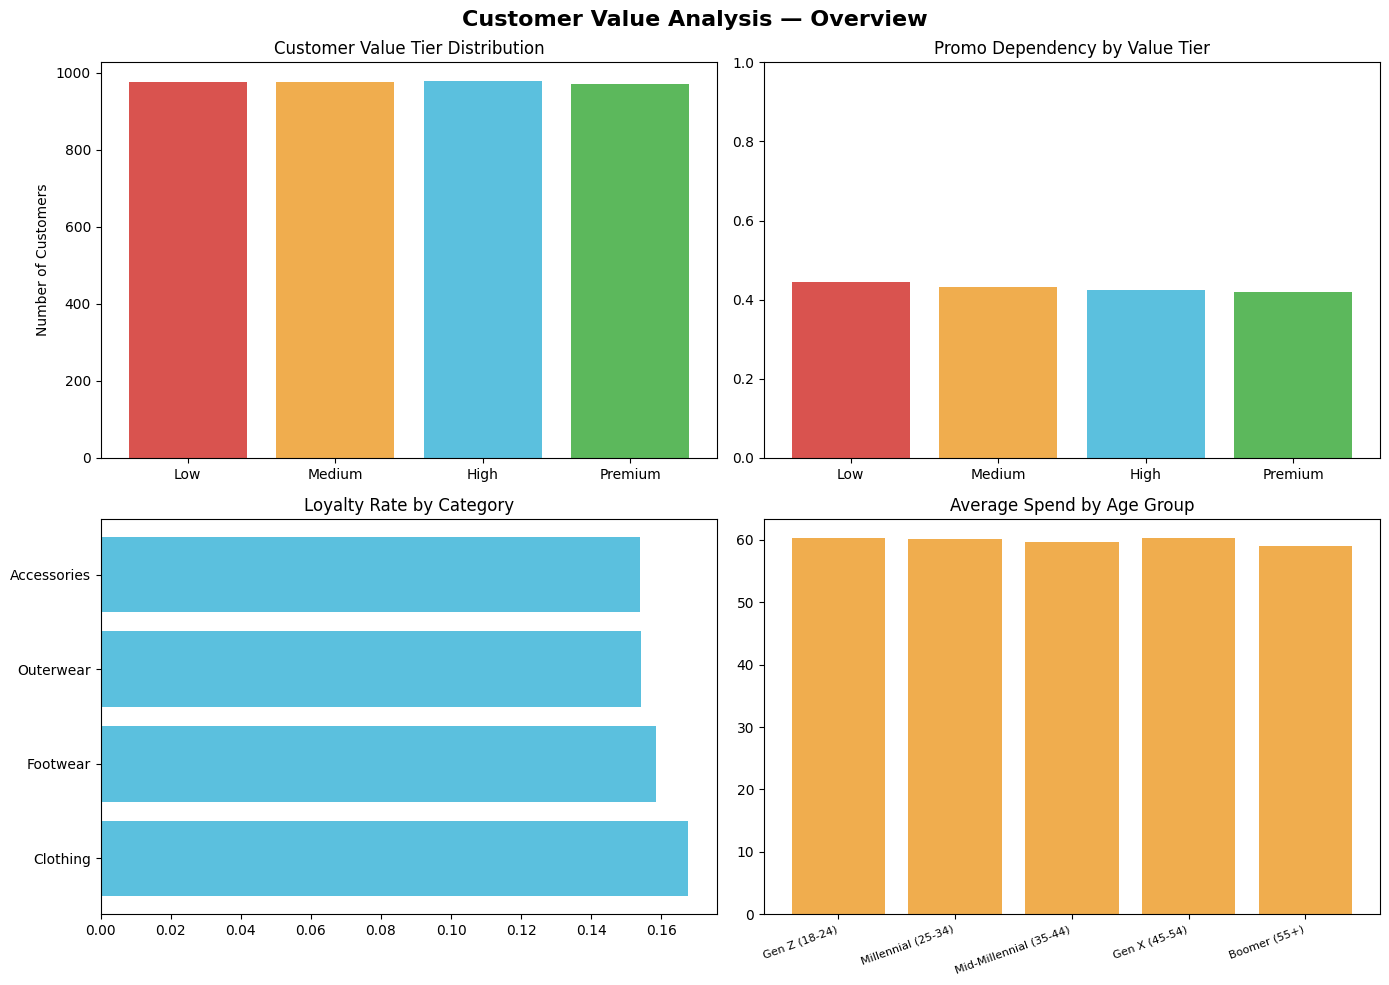

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Customer Value Analysis — Overview', fontsize=16, fontweight='bold')

tier_counts = df['Value_Tier'].value_counts().sort_index()
axes[0,0].bar(tier_counts.index, tier_counts.values, color=['#d9534f','#f0ad4e','#5bc0de','#5cb85c'])
axes[0,0].set_title('Customer Value Tier Distribution')
axes[0,0].set_ylabel('Number of Customers')

tier_promo = df.groupby('Value_Tier', observed=True)['Promo_Dependency_Score'].mean()
axes[0,1].bar(tier_promo.index, tier_promo.values, color=['#d9534f','#f0ad4e','#5bc0de','#5cb85c'])
axes[0,1].set_title('Promo Dependency by Value Tier')
axes[0,1].set_ylim(0, 1)

cat_loyalty = df.groupby('Category')['Loyalty_Def1'].mean().sort_values(ascending=False)
axes[1,0].barh(cat_loyalty.index, cat_loyalty.values, color='#5bc0de')
axes[1,0].set_title('Loyalty Rate by Category')

age_spend = df.groupby('Age_Group', observed=True)['Purchase_Amount_USD'].mean()
axes[1,1].bar(range(len(age_spend)), age_spend.values, color='#f0ad4e')
axes[1,1].set_xticks(range(len(age_spend)))
axes[1,1].set_xticklabels(age_spend.index, rotation=20, ha='right', fontsize=8)
axes[1,1].set_title('Average Spend by Age Group')

plt.tight_layout()
plt.show()

In [19]:
df['Value_Tier'] = df['Value_Tier'].astype(str)
df['Age_Group'] = df['Age_Group'].astype(str)

df.to_csv('customer_value_clean.csv', index=False)
print('Exported: customer_value_clean.csv')
print(f'Shape: {df.shape}')
print(f'Loyal customers: {df["Loyalty_Def1"].sum()}')
print(f'Premium tier: {(df["Value_Tier"]=="Premium").sum()}')


Exported: customer_value_clean.csv
Shape: (3900, 28)
Loyal customers: 627
Premium tier: 970
